# Quickstart: Hydrométrie API

First real-world usage of [`hubeau-data`](https://pypi.org/project/hubeau-data/), installed from PyPI.

We use the **hydrométrie** API to:
1. Check the health of all endpoints
2. Fetch 7 days of real-time flow rate observations for a known station
3. Load the results into a pandas DataFrame and plot the signal

> **Note:** Hub'Eau real-time observations are only available for the past ~1 month.
> The `observations_tr` endpoint uses `code_entite` to filter by site or station code
> (not `code_station` as one might expect from the response fields).

## Setup

In [1]:
from datetime import datetime, timedelta, timezone

import matplotlib.pyplot as plt
import pandas as pd

from hubeau_data.client import HubeauClient
from hubeau_data.models.hydrometrie import ObservationTrParams

client = HubeauClient()

## 1. Health check

`check_health()` probes each endpoint 3 times and returns latency stats.
A `healthy_ratio` of 1.0 means all endpoints are reachable.

In [2]:
health = client.hydrometrie.check_health()
print(health.model_dump_json(indent=2))

{
  "api": "hydrometrie",
  "checked_at": "2026-06-16T18:56:05.859559Z",
  "n_requests_per_endpoint": 3,
  "endpoints": [
    {
      "name": "referentiel/sites",
      "ok": true,
      "latency_ms_avg": 90.6,
      "latency_ms_min": 59.5,
      "latency_ms_max": 127.9,
      "error": null
    },
    {
      "name": "referentiel/stations",
      "ok": true,
      "latency_ms_avg": 63.4,
      "latency_ms_min": 60.7,
      "latency_ms_max": 66.2,
      "error": null
    },
    {
      "name": "observations_tr",
      "ok": true,
      "latency_ms_avg": 387.9,
      "latency_ms_min": 366.0,
      "latency_ms_max": 426.2,
      "error": null
    },
    {
      "name": "obs_elab",
      "ok": true,
      "latency_ms_avg": 2637.9,
      "latency_ms_min": 2576.4,
      "latency_ms_max": 2748.1,
      "error": null
    }
  ],
  "healthy_ratio": 1.0
}


## 2. Fetch real-time observations

Station `O001004003` is on the Garonne river in the Pyrenees (lat ~42.9, lon ~0.69).
We request flow rate (`Q`) observations for the past 7 days.

The Hub'Eau API caps results at 20,000 per page; 2,000 covers ~7 days for this station
(one measurement every ~5 minutes).

In [3]:
since = (datetime.now(timezone.utc) - timedelta(days=7)).strftime("%Y-%m-%dT%H:%M:%SZ")

params = ObservationTrParams(
    code_entite=["O001004003"],
    grandeur_hydro=["Q"],
    date_debut_obs=since,
    size=2000,
    sort="asc",
)

observations = client.hydrometrie.get_observations_tr(params)
print(f"{len(observations.data)} observations fetched")
print(f"from {observations.data[0].date_obs} to {observations.data[-1].date_obs}")

2000 observations fetched
from 2026-06-09T19:00:00Z to 2026-06-16T17:35:00Z


In [4]:
# Inspect the first record — a fully typed Pydantic model
print(observations.data[0].model_dump_json(indent=2))

{
  "code_continuite": 0,
  "code_methode_obs": 8,
  "code_qualification_obs": 16,
  "code_site": "O0010040",
  "code_station": "O001004003",
  "code_statut": 8,
  "code_systeme_alti_serie": 31,
  "date_debut_serie": "2026-06-05T00:00:00Z",
  "date_fin_serie": "2026-06-10T06:00:00Z",
  "date_obs": "2026-06-09T19:00:00Z",
  "grandeur_hydro": "Q",
  "latitude": 42.915355576,
  "libelle_continuite": "Continue",
  "libelle_methode_obs": "Calculée",
  "libelle_qualification_obs": "Non qualifiée",
  "libelle_statut": "Corrigée",
  "longitude": 0.692109399,
  "resultat_obs": 38800.0
}


## 3. Into a DataFrame

Pydantic models expose `model_dump()`, which pandas accepts directly.
No manual field mapping needed.

In [5]:
df = pd.DataFrame([o.model_dump() for o in observations.data])
df["date_obs"] = pd.to_datetime(df["date_obs"])
df = df[["date_obs", "resultat_obs"]].sort_values("date_obs")
df.head()

,date_obs,resultat_obs
0,2026-06-09 19:00:00+00:00,38800.0
1,2026-06-09 19:05:00+00:00,39800.0
2,2026-06-09 19:10:00+00:00,40800.0
3,2026-06-09 19:15:00+00:00,41300.0
4,2026-06-09 19:20:00+00:00,43100.0


## 4. Plot

7-day flow rate signal for the Garonne at station O001004003.

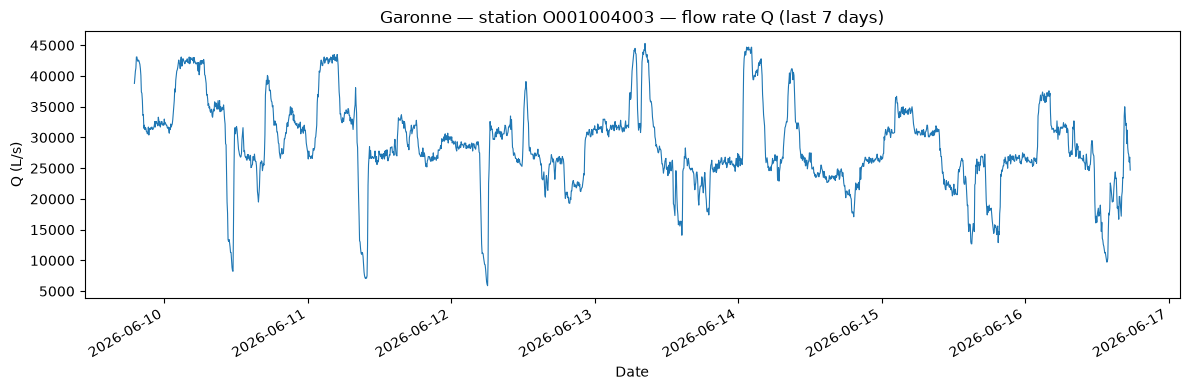

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["date_obs"], df["resultat_obs"], linewidth=0.8)
ax.set_title("Garonne — station O001004003 — flow rate Q (last 7 days)")
ax.set_xlabel("Date")
ax.set_ylabel("Q (L/s)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()